# Module 1 Homework — 2026 Cohort
### Stock Market Analytics Zoomcamp — Introduction and Data Sources

هذا الـ notebook بيحل الأسئلة الأربعة الأساسية في `cohorts/2026/homework1.md`:
1. S&P 500 — أكتر سنة (من 2020) دخلها شركات جديدة للمؤشر
2. Macro — مقارنة عائد YTD للمؤشرات العالمية مع S&P 500 (حتى 21 أغسطس 2026)
3. S&P 500 — تحليل الـ market corrections (median drawdown)
4. Amazon (AMZN) — تحليل رد فعل السهم بعد مفاجآت الأرباح (earnings surprises)

بالإضافة لأسئلة 5 و6 (النصية/الاستكشافية) كتمبليت جاهز تكمله بنفسك.

## 0) Imports

In [1]:
import numpy as np
import pandas as pd
import requests
import yfinance as yf
import matplotlib.pyplot as plt

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}


## Question 1 — S&P 500 Stocks Added to the Index

**السؤال:** أي سنة (من 2020) شافت أعلى عدد إضافات لشركات جديدة في مؤشر S&P 500؟

In [2]:
url_sp500 = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
response = requests.get(url_sp500, headers=headers, timeout=30)
response.raise_for_status()

tables = pd.read_html(response.text)

# أول جدول عادة هو قائمة الشركات الحالية فيها عمود 'Date added'
sp500_df = tables[0].copy()
print(sp500_df.columns.tolist())
sp500_df.head(3)


['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Headquarters Location', 'Date added', 'CIK', 'Founded']


/tmp/ipykernel_1277/4050133266.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888


In [3]:
# تنضيف عمود التاريخ
sp500_df['Date added'] = pd.to_datetime(sp500_df['Date added'], errors='coerce')
sp500_df['Year_added'] = sp500_df['Date added'].dt.year

# عدد الإضافات لكل سنة بداية من 2020
additions_from_2020 = sp500_df[sp500_df['Year_added'] >= 2020]
additions_by_year = additions_from_2020.groupby('Year_added').size().sort_values(ascending=False)

print("عدد الإضافات لكل سنة (من 2020):")
print(additions_by_year)

best_year = int(additions_by_year.index[0])
print(f"\n>>> أعلى سنة إضافات (من 2020) = {best_year} بعدد {int(additions_by_year.iloc[0])} إضافة")


عدد الإضافات لكل سنة (من 2020):
Year_added
2025    17
2024    16
2026    16
2022    15
2023    14
2021    10
2020    10
dtype: int64

>>> أعلى سنة إضافات (من 2020) = 2025 بعدد 17 إضافة


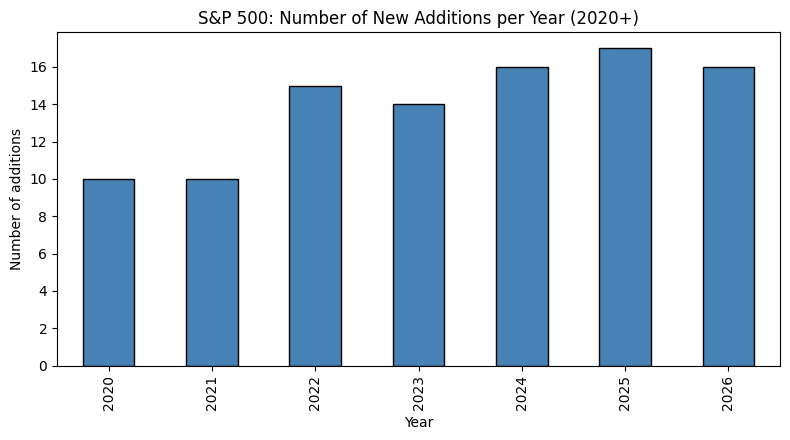

In [4]:
# رسم بياني لعدد الإضافات حسب السنة
fig, ax = plt.subplots(figsize=(8, 4.5))
additions_by_year.sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('S&P 500: Number of New Additions per Year (2020+)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of additions')
plt.tight_layout()
plt.show()


### Additional: كام سهم في المؤشر حاليًا موجود من أكتر من 20 سنة؟

In [5]:
today = pd.Timestamp.today()
cutoff_20y = today - pd.DateOffset(years=20)

stocks_over_20y = sp500_df[sp500_df['Date added'] <= cutoff_20y]
print(f"عدد الأسهم اللي دخلت المؤشر من أكتر من 20 سنة (قبل {cutoff_20y.date()}): {len(stocks_over_20y)}")
print(f"من إجمالي {sp500_df['Date added'].notna().sum()} سهم عندهم تاريخ إضافة معروف")


عدد الأسهم اللي دخلت المؤشر من أكتر من 20 سنة (قبل 2006-09-21): 223
من إجمالي 503 سهم عندهم تاريخ إضافة معروف


## Question 2 — Indexes YTD Performance (as of 21 August 2026)

**السؤال:** كام مؤشر (من أصل 10) عنده عائد YTD أفضل من S&P 500 حتى 21 أغسطس 2026؟

In [7]:
df = yf.download('^GSPC', start='2026-01-01', end='2026-08-21', progress=False)
print(type(df.columns))
print(df.columns.tolist())
print(type(df.iloc[0]))

<class 'pandas.core.indexes.multi.MultiIndex'>
[('Close', '^GSPC'), ('High', '^GSPC'), ('Low', '^GSPC'), ('Open', '^GSPC'), ('Volume', '^GSPC')]
<class 'pandas.core.series.Series'>


/tmp/ipykernel_1277/2131215222.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('^GSPC', start='2026-01-01', end='2026-08-21', progress=False)


In [6]:
indices = {
    'United States (S&P 500)': '^GSPC',
    'China (Shanghai Composite)': '000001.SS',
    'Hong Kong (HANG SENG)': '^HSI',
    'Australia (S&P/ASX 200)': '^AXJO',
    'India (Nifty 50)': '^NSEI',
    'Canada (S&P/TSX Composite)': '^GSPTSE',
    'Germany (DAX)': '^GDAXI',
    'United Kingdom (FTSE 100)': '^FTSE',
    'Japan (Nikkei 225)': '^N225',
    'Mexico (IPC Mexico)': '^MXX',
    'Brazil (Ibovespa)': '^BVSP',
}

start_date = '2026-01-01'
end_date = '2026-08-21'

ytd_returns = {}
for name, ticker in indices.items():
    try:
        df = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if df.empty:
            print(f"[WARN] No data for {name} ({ticker})")
            continue
        df = df.sort_index()
        close_col = 'Close' if 'Close' in df.columns else df.columns[0]
        first_close = df[close_col].iloc[0]
        last_close = df[close_col].iloc[-1]
        ytd_return = (last_close / first_close) - 1
        ytd_returns[name] = ytd_return
    except Exception as e:
        print(f"[WARN] Failed to download {name} ({ticker}): {e}")

ytd_df = pd.Series(ytd_returns, name='YTD_return').sort_values(ascending=False).to_frame()
ytd_df['YTD_return_%'] = (ytd_df['YTD_return'] * 100).round(2)
ytd_df


/tmp/ipykernel_1277/3252324715.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_1277/3252324715.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_1277/3252324715.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_1277/3252324715.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_1277/3252324715.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_1277/3252324715.py:21: FutureW

ValueError: Can only compare identically-labeled Series objects

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np

indices = {
    'United States (S&P 500)': '^GSPC',
    'China (Shanghai Composite)': '000001.SS',
    'Hong Kong (HANG SENG)': '^HSI',
    'Australia (S&P/ASX 200)': '^AXJO',
    'India (Nifty 50)': '^NSEI',
    'Canada (S&P/TSX Composite)': '^GSPTSE',
    'Germany (DAX)': '^GDAXI',
    'United Kingdom (FTSE 100)': '^FTSE',
    'Japan (Nikkei 225)': '^N225',
    'Mexico (IPC Mexico)': '^MXX',
    'Brazil (Ibovespa)': '^BVSP',
}

def flatten_yf_columns(df: pd.DataFrame) -> pd.DataFrame:
    """لو الأعمدة MultiIndex (زي yfinance الجديد)، رجّعها single-level."""
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df

def get_close_series(ticker: str, start: str, end: str) -> pd.Series:
    """يرجّع Close كـ Series نظيفة (single-level index)."""
    df = yf.download(ticker, start=start, end=end,
                     progress=False, auto_adjust=True)
    if df is None or df.empty:
        return pd.Series(dtype=float)
    df = flatten_yf_columns(df)
    if 'Close' in df.columns:
        return df['Close'].dropna()
    return df.iloc[:, 0].dropna()

start_date = '2026-01-01'
end_date   = '2026-08-21'

ytd_returns = {}
for name, ticker in indices.items():
    try:
        close = get_close_series(ticker, start_date, end_date)
        if close.empty:
            print(f"[WARN] No data for {name} ({ticker})")
            continue
        first_close = float(close.iloc[0])
        last_close  = float(close.iloc[-1])
        ytd_returns[name] = (last_close / first_close) - 1
    except Exception as e:
        print(f"[WARN] Failed {name} ({ticker}): {e}")

ytd_df = (
    pd.Series(ytd_returns, name='YTD_return')
      .sort_values(ascending=False)
      .to_frame()
)
ytd_df['YTD_return_%'] = (ytd_df['YTD_return'] * 100).round(2)
ytd_df

,YTD_return,YTD_return_%
Japan (Nikkei 225),0.277507,27.75
Canada (S&P/TSX Composite),0.140575,14.06
United States (S&P 500),0.114120,11.41
United Kingdom (FTSE 100),0.080102,8.01
Germany (DAX),0.058832,5.88
Brazil (Ibovespa),0.046020,4.60
Australia (S&P/ASX 200),0.040789,4.08
Mexico (IPC Mexico),0.003250,0.32
Hong Kong (HANG SENG),-0.024298,-2.43
China (Shanghai Composite),-0.029750,-2.97


In [9]:
us_ytd = ytd_returns.get('United States (S&P 500)', np.nan)
better_than_us = {k: v for k, v in ytd_returns.items() if k != 'United States (S&P 500)' and v > us_ytd}

print(f"عائد S&P 500 YTD = {us_ytd:.2%}")
print(f"\nعدد المؤشرات (من أصل 10 غير أمريكا) اللي أداؤها أفضل من S&P 500 = {len(better_than_us)}")
for k, v in sorted(better_than_us.items(), key=lambda x: -x[1]):
    print(f"  - {k}: {v:.2%}")


عائد S&P 500 YTD = 11.41%

عدد المؤشرات (من أصل 10 غير أمريكا) اللي أداؤها أفضل من S&P 500 = 2
  - Japan (Nikkei 225): 27.75%
  - Canada (S&P/TSX Composite): 14.06%


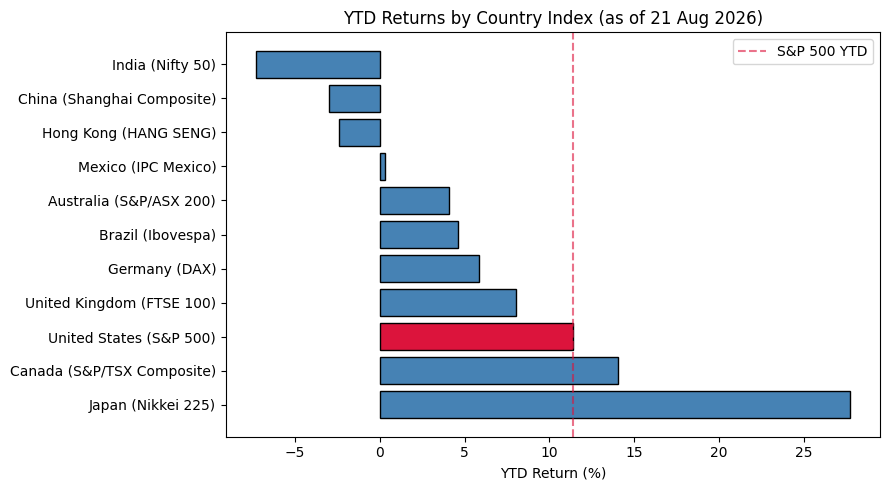

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if k == 'United States (S&P 500)' else 'steelblue' for k in ytd_df.index]
ax.barh(ytd_df.index, ytd_df['YTD_return_%'], color=colors, edgecolor='black')
ax.axvline(us_ytd * 100, color='crimson', linestyle='--', alpha=0.6, label='S&P 500 YTD')
ax.set_title('YTD Returns by Country Index (as of 21 Aug 2026)')
ax.set_xlabel('YTD Return (%)')
ax.legend()
plt.tight_layout()
plt.show()


### Additional: أداء المؤشرات على 3، 5، 10 سنين مقارنة بـ S&P 500

In [11]:
def period_return(ticker, years, end_date='2026-08-21'):
    end_dt = pd.Timestamp(end_date)
    start_dt = end_dt - pd.DateOffset(years=years)
    df = yf.download(ticker, start=start_dt.strftime('%Y-%m-%d'), end=end_date, progress=False)
    if df.empty:
        return np.nan
    df = df.sort_index()
    close_col = 'Close' if 'Close' in df.columns else df.columns[0]
    return df[close_col].iloc[-1] / df[close_col].iloc[0] - 1

multi_period_returns = {}
for name, ticker in indices.items():
    row = {}
    for yrs in [3, 5, 10]:
        try:
            row[f'{yrs}Y_return'] = period_return(ticker, yrs)
        except Exception as e:
            print(f"[WARN] {name} {yrs}Y failed: {e}")
            row[f'{yrs}Y_return'] = np.nan
    multi_period_returns[name] = row

multi_period_df = pd.DataFrame(multi_period_returns).T
us_row = multi_period_df.loc['United States (S&P 500)']

for yrs in [3, 5, 10]:
    col = f'{yrs}Y_return'
    n_better = (multi_period_df[col] > us_row[col]).sum() - (1 if False else 0)
    # نطرح صف أمريكا نفسه من العد
    n_better = (multi_period_df.drop('United States (S&P 500)')[col] > us_row[col]).sum()
    print(f"{yrs}-year: {n_better} مؤشر أداؤه أفضل من S&P 500 (S&P 500 = {us_row[col]:.1%})")

multi_period_df.style.format('{:.1%}')


/tmp/ipykernel_1277/4229207190.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_dt.strftime('%Y-%m-%d'), end=end_date, progress=False)
/tmp/ipykernel_1277/4229207190.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_dt.strftime('%Y-%m-%d'), end=end_date, progress=False)
/tmp/ipykernel_1277/4229207190.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_dt.strftime('%Y-%m-%d'), end=end_date, progress=False)
/tmp/ipykernel_1277/4229207190.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_dt.strftime('%Y-%m-%d'), end=end_date, progress=False)
/tmp/ipykernel_1277/4229207190.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_dt.strftim

ValueError: Can only compare identically-labeled Series objects

In [12]:
def period_return(ticker, years, end_date='2026-08-21'):
    """يرجّع عائد فترة (بالسنين) كـ scalar."""
    end_dt = pd.Timestamp(end_date)
    start_dt = end_dt - pd.DateOffset(years=years)

    # ✅ نفس الـ helper اللي عملناه قبل كده
    close = get_close_series(
        ticker,
        start_dt.strftime('%Y-%m-%d'),
        end_date
    )

    if close.empty:
        return np.nan

    first_close = float(close.iloc[0])
    last_close  = float(close.iloc[-1])
    return last_close / first_close - 1


multi_period_returns = {}
for name, ticker in indices.items():
    row = {}
    for yrs in [3, 5, 10]:
        try:
            row[f'{yrs}Y_return'] = period_return(ticker, yrs)
        except Exception as e:
            print(f"[WARN] {name} {yrs}Y failed: {e}")
            row[f'{yrs}Y_return'] = np.nan
    multi_period_returns[name] = row

multi_period_df = pd.DataFrame(multi_period_returns).T
us_row = multi_period_df.loc['United States (S&P 500)']

for yrs in [3, 5, 10]:
    col = f'{yrs}Y_return'
    n_better = (multi_period_df.drop('United States (S&P 500)')[col] > us_row[col]).sum()
    print(f"{yrs}-year: {n_better} مؤشر أداؤه أفضل من S&P 500 (S&P 500 = {us_row[col]:.1%})")

multi_period_df.style.format('{:.1%}')

3-year: 2 مؤشر أداؤه أفضل من S&P 500 (S&P 500 = 73.7%)
5-year: 2 مؤشر أداؤه أفضل من S&P 500 (S&P 500 = 70.6%)
10-year: 1 مؤشر أداؤه أفضل من S&P 500 (S&P 500 = 250.1%)


,3Y_return,5Y_return,10Y_return
United States (S&P 500),73.7%,70.6%,250.1%
China (Shanghai Composite),26.2%,12.3%,26.5%
Hong Kong (HANG SENG),45.8%,2.3%,11.7%
Australia (S&P/ASX 200),27.7%,21.3%,64.7%
India (Nifty 50),24.9%,46.9%,180.8%
Canada (S&P/TSX Composite),83.8%,77.6%,146.6%
Germany (DAX),66.5%,63.9%,147.6%
United Kingdom (FTSE 100),48.1%,51.2%,57.4%
Japan (Nikkei 225),109.8%,140.8%,298.9%
Mexico (IPC Mexico),21.2%,23.6%,33.2%


## Question 3 — S&P 500 Market Corrections Analysis

**السؤال:** احسب الـ median drawdown (%) لتصحيحات السوق الملحوظة (≥5% هبوط من أعلى قمة سابقة) في S&P 500 من 1950 لحد دلوقتي.

In [13]:
sp500_hist = yf.download('^GSPC', start='1950-01-01', progress=False)
sp500_hist = sp500_hist.sort_index()
close_col = 'Close' if 'Close' in sp500_hist.columns else sp500_hist.columns[0]
close = sp500_hist[close_col].dropna()

print(f"Data range: {close.index.min().date()} to {close.index.max().date()}  ({len(close)} trading days)")


/tmp/ipykernel_1277/2197198329.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_hist = yf.download('^GSPC', start='1950-01-01', progress=False)


Data range: 1950-01-03 to 2026-09-18  (19300 trading days)


In [14]:
# 1) نحدد كل الأيام اللي فيها the price بيعمل all-time high جديد (>= كل القيم اللي قبلها)
running_max = close.cummax()
is_ath = close >= running_max
ath_dates = close.index[is_ath]
ath_prices = close[is_ath]

print(f"Number of all-time-high days identified: {len(ath_dates)}")

# 2) لكل زوج قمم متتاليين، نلاقي أقل سعر بينهم، ونحسب الـ drawdown والمدة
corrections = []
for i in range(len(ath_dates) - 1):
    peak_date = ath_dates[i]
    next_peak_date = ath_dates[i + 1]
    peak_price = ath_prices.iloc[i]

    segment = close.loc[peak_date:next_peak_date]
    trough_price = segment.min()
    trough_date = segment.idxmin()

    drawdown_pct = (peak_price - trough_price) / peak_price * 100

    if drawdown_pct >= 5:  # نفلتر بس الـ corrections الملحوظة (>= 5%)
        duration_days = (trough_date - peak_date).days
        corrections.append({
            'peak_date': peak_date, 'peak_price': float(peak_price),
            'trough_date': trough_date, 'trough_price': float(trough_price),
            'drawdown_pct': drawdown_pct, 'duration_days': duration_days,
        })

corrections_df = pd.DataFrame(corrections)
print(f"\nNumber of corrections with drawdown >= 5%: {len(corrections_df)}")
corrections_df.sort_values('drawdown_pct', ascending=False).head(10)


TypeError: Cannot pass DataFrame to 'pandas.array'

In [15]:
# ✅ helper جاهز
def flatten_yf_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df


# ✅ حمّل الـ S&P 500 history بشكل نظيف
sp500_hist = yf.download(
    '^GSPC',
    start='1950-01-01',
    progress=False,
    auto_adjust=True,   # يمنع FutureWarning
)
sp500_hist = sp500_hist.sort_index()

# ✅ اضغط الـ MultiIndex
sp500_hist = flatten_yf_columns(sp500_hist)

# ✅ دلوقتي close Series حقيقية
close = sp500_hist['Close'].dropna()

print(f"Data range: {close.index.min().date()} to {close.index.max().date()}  ({len(close)} trading days)")
print(f"Type of close: {type(close)}")
print(f"Type of close.iloc[0]: {type(close.iloc[0])}")

Data range: 1950-01-03 to 2026-09-18  (19300 trading days)
Type of close: <class 'pandas.core.series.Series'>
Type of close.iloc[0]: <class 'numpy.float64'>


In [16]:
# مقارنة مع أكبر 10 تصحيحات معروفة تاريخيًا (من نص الواجب) كـ sanity check
print("Top 10 largest corrections found in our data:")
display(corrections_df.sort_values('drawdown_pct', ascending=False).head(10)
        [['peak_date', 'trough_date', 'drawdown_pct', 'duration_days']])


Top 10 largest corrections found in our data:


NameError: name 'corrections_df' is not defined

In [17]:
def flatten_yf_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df


sp500_hist = yf.download('^GSPC', start='1950-01-01',
                         progress=False, auto_adjust=True)
sp500_hist = sp500_hist.sort_index()
sp500_hist = flatten_yf_columns(sp500_hist)

close = sp500_hist['Close'].dropna()

print(f"Data range: {close.index.min().date()} to {close.index.max().date()}  ({len(close)} trading days)")

Data range: 1950-01-03 to 2026-09-18  (19300 trading days)


In [18]:
running_max = close.cummax()
is_ath = close >= running_max
ath_dates = close.index[is_ath]
ath_prices = close[is_ath]

print(f"Number of all-time-high days identified: {len(ath_dates)}")

corrections = []
for i in range(len(ath_dates) - 1):
    peak_date = ath_dates[i]
    next_peak_date = ath_dates[i + 1]
    peak_price = ath_prices.iloc[i]

    segment = close.loc[peak_date:next_peak_date]
    trough_price = segment.min()
    trough_date = segment.idxmin()

    drawdown_pct = (peak_price - trough_price) / peak_price * 100

    if drawdown_pct >= 5:
        duration_days = (trough_date - peak_date).days
        corrections.append({
            'peak_date': peak_date,
            'peak_price': float(peak_price),
            'trough_date': trough_date,
            'trough_price': float(trough_price),
            'drawdown_pct': drawdown_pct,
            'duration_days': duration_days,
        })

corrections_df = pd.DataFrame(corrections)

# ✅ تحقق إنها اتبنت فعلًا
print(f"Number of corrections with drawdown >= 5%: {len(corrections_df)}")
print("corrections_df is defined:", 'corrections_df' in dir())
print(corrections_df.head())

Number of all-time-high days identified: 1537
Number of corrections with drawdown >= 5%: 74
corrections_df is defined: True
   peak_date  peak_price trough_date  trough_price  drawdown_pct  \
0 1950-06-12   19.400000  1950-07-17     16.680000     14.020615   
1 1950-11-24   20.320000  1950-12-04     19.000000      6.496062   
2 1951-05-03   22.809999  1951-06-29     20.959999      8.110480   
3 1951-10-15   23.850000  1951-11-23     22.400000      6.079668   
4 1952-01-22   24.660000  1952-02-20     23.090000      6.366584   

   duration_days  
0             35  
1             10  
2             57  
3             39  
4             29  


In [19]:
print("Top 10 largest corrections found in our data:")
display(
    corrections_df.sort_values('drawdown_pct', ascending=False)
    .head(10)[['peak_date', 'trough_date', 'drawdown_pct', 'duration_days']]
)

Top 10 largest corrections found in our data:


,peak_date,trough_date,drawdown_pct,duration_days
56,2007-10-09,2009-03-09,56.775388,517
54,2000-03-24,2002-10-09,49.146948,929
24,1973-01-11,1974-10-03,48.203593,630
22,1968-11-29,1970-05-26,36.061641,543
65,2020-02-19,2020-03-23,33.924960,33
35,1987-08-25,1987-12-04,33.509515,101
15,1961-12-12,1962-06-26,27.973568,196
27,1980-11-28,1982-08-12,27.113582,622
68,2022-01-03,2022-10-12,25.425097,282
18,1966-02-09,1966-10-07,22.177335,240


In [20]:
quantiles = [0.25, 0.5, 0.75]

drawdown_quantiles = corrections_df['drawdown_pct'].quantile(quantiles)
duration_quantiles = corrections_df['duration_days'].quantile(quantiles)

summary_q3 = pd.DataFrame({
    'drawdown_pct': drawdown_quantiles,
    'duration_days': duration_quantiles,
})
summary_q3.index = ['25th percentile', '50th percentile (median)', '75th percentile']
display(summary_q3)

median_drawdown = corrections_df['drawdown_pct'].median()
median_duration = corrections_df['duration_days'].median()
print(f"\n>>> Median drawdown of significant corrections = {median_drawdown:.1f}%")
print(f">>> Median duration = {median_duration:.0f} days")


,drawdown_pct,duration_days
25th percentile,6.234677,22.00
50th percentile (median),7.986358,40.50
75th percentile,14.019826,86.25



>>> Median drawdown of significant corrections = 8.0%
>>> Median duration = 40 days


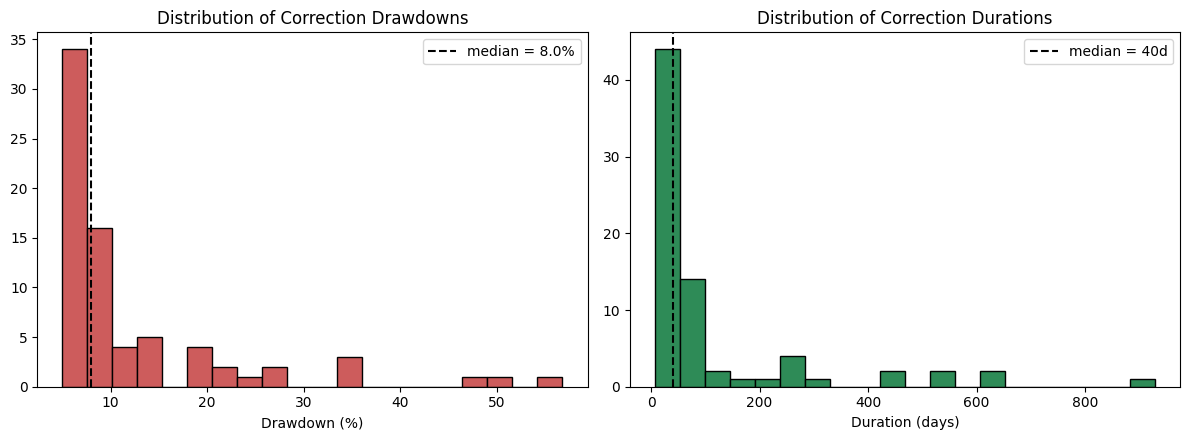

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(corrections_df['drawdown_pct'], bins=20, color='indianred', edgecolor='black')
axes[0].axvline(median_drawdown, color='black', linestyle='--', label=f'median = {median_drawdown:.1f}%')
axes[0].set_title('Distribution of Correction Drawdowns')
axes[0].set_xlabel('Drawdown (%)')
axes[0].legend()

axes[1].hist(corrections_df['duration_days'], bins=20, color='seagreen', edgecolor='black')
axes[1].axvline(median_duration, color='black', linestyle='--', label=f'median = {median_duration:.0f}d')
axes[1].set_title('Distribution of Correction Durations')
axes[1].set_xlabel('Duration (days)')
axes[1].legend()

plt.tight_layout()
plt.show()


## Question 4 — Earnings Surprise Analysis for Amazon (AMZN)

**السؤال:** احسب الـ median لعائد يومين (2-day %) بعد أيام الـ positive earnings surprise.

In [22]:
ticker_obj = yf.Ticker('AMZN')
earnings_dates_df = ticker_obj.get_earnings_dates(limit=30)
print(earnings_dates_df.shape)
earnings_dates_df.head(10)


(50, 3)


,EPS Estimate,Reported EPS,Surprise(%)
Earnings Date,,,
2026-10-29 16:00:00-04:00,1.95,NaN,NaN
2026-07-30 16:00:00-04:00,1.83,5.75,215.02
2026-04-29 16:00:00-04:00,1.65,2.78,68.18
2026-02-05 16:00:00-05:00,1.95,1.95,0.22
2025-10-30 16:00:00-04:00,1.56,1.95,25.20
2025-07-31 16:00:00-04:00,1.33,1.68,26.13
2025-05-01 16:00:00-04:00,1.36,1.59,17.08
2025-02-06 16:00:00-05:00,1.48,1.86,25.36
2024-10-31 16:00:00-04:00,1.14,1.43,25.17


In [23]:
amzn_hist = yf.download('AMZN', period='max', interval='1d', progress=False)
amzn_hist = amzn_hist.sort_index()
close_col_amzn = 'Close' if 'Close' in amzn_hist.columns else amzn_hist.columns[0]
amzn_close = amzn_hist[close_col_amzn].dropna()

print(f"AMZN price history: {amzn_close.index.min().date()} to {amzn_close.index.max().date()}")


/tmp/ipykernel_1277/4270417520.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  amzn_hist = yf.download('AMZN', period='max', interval='1d', progress=False)


AMZN price history: 1997-05-15 to 2026-09-18


In [25]:
print("type(amzn_close):", type(amzn_close))
print("shape:", amzn_close.shape if hasattr(amzn_close, 'shape') else 'n/a')
print("columns:", amzn_close.columns.tolist() if hasattr(amzn_close, 'columns') else 'n/a')
print("iloc[0]:", type(amzn_close.iloc[0]))

type(amzn_close): <class 'pandas.core.frame.DataFrame'>
shape: (7382, 1)
columns: ['AMZN']
iloc[0]: <class 'pandas.core.series.Series'>


In [24]:
def two_day_return_after(event_date: pd.Timestamp, price_series: pd.Series):
    """
    Day1 = أول يوم تداول عند/بعد تاريخ الحدث (ممكن يكون هو يوم الإعلان أو أقرب يوم بعده)
    Day3 = بعد يومين تداول من Day1 (positional indexing)
    Return = Close_Day3 / Close_Day1 - 1
    """
    idx = price_series.index
    valid_dates = idx[idx >= event_date]
    if len(valid_dates) == 0:
        return np.nan
    pos = idx.get_loc(valid_dates[0])
    if pos + 2 >= len(idx):
        return np.nan
    day1_price = price_series.iloc[pos]
    day3_price = price_series.iloc[pos + 2]
    if pd.isna(day1_price) or pd.isna(day3_price) or day1_price == 0:
        return np.nan
    return day3_price / day1_price - 1


earnings_analysis = earnings_dates_df.copy()
earnings_analysis.index = pd.to_datetime(earnings_analysis.index).tz_localize(None)

earnings_analysis['2d_return'] = [
    two_day_return_after(d, amzn_close) for d in earnings_analysis.index
]

# عمود الـ Surprise % ممكن يكون اسمه مختلف شوية حسب نسخة yfinance
surprise_col_candidates = [c for c in earnings_analysis.columns if 'surprise' in c.lower()]
print("Surprise column(s) found:", surprise_col_candidates)
surprise_col = surprise_col_candidates[0] if surprise_col_candidates else None

earnings_analysis = earnings_analysis.dropna(subset=['2d_return'])
earnings_analysis.head(10)


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [26]:
def flatten_yf_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df


amzn_hist = yf.download('AMZN', period='max', interval='1d',
                        progress=False, auto_adjust=True)
amzn_hist = amzn_hist.sort_index()
amzn_hist = flatten_yf_columns(amzn_hist)   # ← الخطوة الحاسمة

# ✅ دلوقتي close Series حقيقية
amzn_close = amzn_hist['Close'].dropna()

print(f"AMZN price history: {amzn_close.index.min().date()} to {amzn_close.index.max().date()}")
print(f"type(amzn_close) = {type(amzn_close)}")                # Series
print(f"type(amzn_close.iloc[0]) = {type(amzn_close.iloc[0])}")  # float
print(f"shape = {amzn_close.shape}")                            # (7382,)

AMZN price history: 1997-05-15 to 2026-09-18
type(amzn_close) = <class 'pandas.core.series.Series'>
type(amzn_close.iloc[0]) = <class 'numpy.float64'>
shape = (7382,)


In [27]:
ticker_obj = yf.Ticker('AMZN')
earnings_dates_df = ticker_obj.get_earnings_dates(limit=30)

earnings_analysis = earnings_dates_df.copy()

# ✅ اتعامل مع tz بأمان
idx = pd.to_datetime(earnings_analysis.index)
if getattr(idx, 'tz', None) is not None:
    idx = idx.tz_localize(None)
earnings_analysis.index = idx

# ✅ دلوقتي two_day_return_after هيشتغل عادي
earnings_analysis['2d_return'] = [
    two_day_return_after(d, amzn_close) for d in earnings_analysis.index
]

# ... باقي الكود زي ما هو
surprise_col_candidates = [c for c in earnings_analysis.columns if 'surprise' in c.lower()]
print("Surprise column(s) found:", surprise_col_candidates)
surprise_col = surprise_col_candidates[0] if surprise_col_candidates else None

earnings_analysis = earnings_analysis.dropna(subset=['2d_return'])
earnings_analysis.head(10)

Surprise column(s) found: ['Surprise(%)']


,EPS Estimate,Reported EPS,Surprise(%),2d_return
Earnings Date,,,,
2026-07-30 16:00:00,1.83,5.75,215.02,0.021504
2026-04-29 16:00:00,1.65,2.78,68.18,0.026371
2026-02-05 16:00:00,1.95,1.95,0.22,-0.015976
2025-10-30 16:00:00,1.56,1.95,25.20,0.020883
2025-07-31 16:00:00,1.33,1.68,26.13,-0.004657
2025-05-01 16:00:00,1.36,1.59,17.08,-0.026161
2025-02-06 16:00:00,1.48,1.86,25.36,0.015754
2024-10-31 16:00:00,1.14,1.43,25.17,0.007932
2024-08-01 12:00:00,1.02,1.26,23.76,-0.035557


In [28]:
if surprise_col is not None:
    earnings_analysis[surprise_col] = pd.to_numeric(earnings_analysis[surprise_col], errors='coerce')

    positive_surprises = earnings_analysis[earnings_analysis[surprise_col] > 0]

    median_2d_return_positive = positive_surprises['2d_return'].median()
    print(f"Number of positive-surprise earnings events: {len(positive_surprises)}")
    print(f">>> Median 2-day return after POSITIVE earnings surprises = {median_2d_return_positive:.2%}")

    corr_matrix = earnings_analysis[[surprise_col, '2d_return']].corr()
    print("\nCorrelation matrix:")
    display(corr_matrix)

    correlation = corr_matrix.loc[surprise_col, '2d_return']
    print(f"\n>>> Correlation between surprise magnitude and 2-day return = {correlation:.3f}")
else:
    print("[WARN] Surprise % column not found in this yfinance version — تأكد من التحديث: pip install -U yfinance")


Number of positive-surprise earnings events: 36
>>> Median 2-day return after POSITIVE earnings surprises = 0.51%

Correlation matrix:


,Surprise(%),2d_return
Surprise(%),1.000000,0.065133
2d_return,0.065133,1.000000



>>> Correlation between surprise magnitude and 2-day return = 0.065


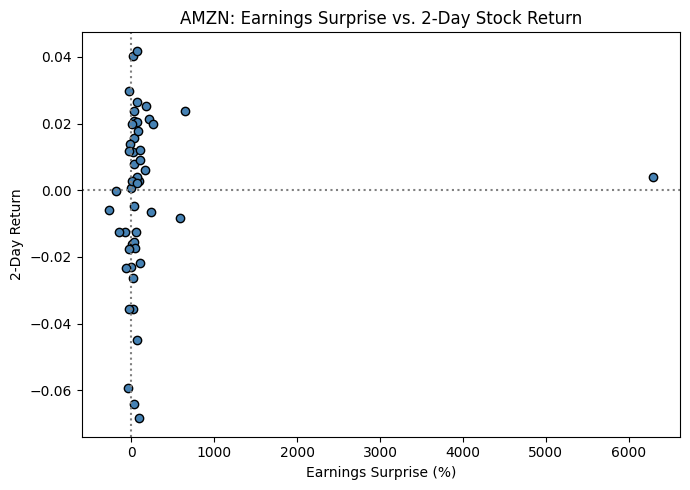

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))
if surprise_col is not None:
    ax.scatter(earnings_analysis[surprise_col], earnings_analysis['2d_return'], color='steelblue', edgecolor='black')
    ax.axhline(0, color='gray', linestyle=':')
    ax.axvline(0, color='gray', linestyle=':')
    ax.set_xlabel('Earnings Surprise (%)')
    ax.set_ylabel('2-Day Return')
    ax.set_title('AMZN: Earnings Surprise vs. 2-Day Stock Return')
    plt.tight_layout()
    plt.show()


## ملخص الإجابات النهائية

In [30]:
print("Q1) أعلى سنة إضافات لمؤشر S&P 500 (من 2020) =", best_year,
      "| عدد الأسهم في المؤشر من أكتر من 20 سنة =", len(stocks_over_20y))
print("Q2) عدد المؤشرات (من 10) اللي أداؤها أفضل من S&P 500 YTD حتى 21 أغسطس 2026 =", len(better_than_us))
print("Q3) Median drawdown للتصحيحات الملحوظة (S&P 500, 1950-present) =", f"{median_drawdown:.1f}%",
      "| median duration =", f"{median_duration:.0f} يوم")
if surprise_col is not None:
    print("Q4) Median عائد يومين بعد positive earnings surprise (AMZN) =", f"{median_2d_return_positive:.2%}",
          "| correlation مع حجم المفاجأة =", f"{correlation:.3f}")


Q1) أعلى سنة إضافات لمؤشر S&P 500 (من 2020) = 2025 | عدد الأسهم في المؤشر من أكتر من 20 سنة = 223
Q2) عدد المؤشرات (من 10) اللي أداؤها أفضل من S&P 500 YTD حتى 21 أغسطس 2026 = 2
Q3) Median drawdown للتصحيحات الملحوظة (S&P 500, 1950-present) = 8.0% | median duration = 40 يوم
Q4) Median عائد يومين بعد positive earnings surprise (AMZN) = 0.51% | correlation مع حجم المفاجأة = 0.065


## Question 5 — [استكشافي، اختياري] فكرة مشروع التخرج (Capstone)

> مثال للإجابة (عدّلها حسب اهتمامك الفعلي):

أنا مهتم ببناء نموذج تنبؤ قصير المدى (30-60 يوم) لأسهم الشركات التقنية متوسطة القيمة السوقية في السوق الأمريكي،
باستخدام مزيج من:
- مؤشرات فنية (RSI, MACD, Bollinger Bands)
- بيانات الاكتتابات الحديثة (IPO momentum) زي اللي حللناها في Module 2
- عوامل ماكرو (أسعار الفائدة، مؤشر VIX)

الهدف: نموذج تصنيف (classification) يتنبأ هل السهم هيحقق عائد أعلى من السوق (S&P 500) خلال فترة زمنية محددة ولا لأ.

###  Phase 0 — Setup & Imports

In [31]:
# ============================================================
# Phase 0: Setup
# ============================================================

import numpy as np
import pandas as pd
import yfinance as yf
import requests
import time
import warnings
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ML
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup done ✅")

Setup done ✅


###  Phase 1 — Universe Selection

In [32]:
# ============================================================
# Phase 1: Build the stock universe (mid-cap US stocks)
# ============================================================

def get_sp500_tickers():
    """جيب قائمة S&P 500 من ويكيبيديا"""
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0'}
    resp = requests.get(url, headers=headers, timeout=30)
    tables = pd.read_html(resp.text)
    df = tables[0]
    return df[['Symbol', 'GICS Sector']].rename(columns={'GICS Sector': 'Sector'})


def get_sp400_tickers():
    """جيب قائمة S&P 400 MidCap من ويكيبيديا"""
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_400_companies'
    headers = {'User-Agent': 'Mozilla/5.0'}
    resp = requests.get(url, headers=headers, timeout=30)
    tables = pd.read_html(resp.text)
    df = tables[0]
    return df[['Symbol', 'GICS Sector']].rename(columns={'GICS Sector': 'Sector'})


# S&P 400 MidCap = الـ universe الأساسي بتاعنا (mid-cap)
universe_df = get_sp400_tickers()
print(f"Universe size (S&P 400 MidCap): {len(universe_df)}")
print(universe_df.head())

# ✅ احفظها عشان تستخدمها بعدين
universe_df.to_csv('universe_midcap.csv', index=False)

Universe size (S&P 400 MidCap): 400
  Symbol            Sector
0     AA         Materials
1    AAL       Industrials
2   AAON       Industrials
3    ACI  Consumer Staples
4    ACM       Industrials


### Phase 2 — Data Collection

In [33]:
# ============================================================
# Phase 2a: Helper functions
# ============================================================

def flatten_yf_columns(df: pd.DataFrame) -> pd.DataFrame:
    """لو الأعمدة MultiIndex (yfinance الجديد)، رجّعها single-level."""
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df


def get_close_series(ticker: str, **kwargs) -> pd.Series:
    """يرجّع Close كـ Series نظيفة."""
    kwargs.setdefault('auto_adjust', True)
    kwargs.setdefault('progress', False)
    df = yf.download(ticker, **kwargs)
    if df is None or df.empty:
        return pd.Series(dtype=float)
    df = flatten_yf_columns(df)
    col = 'Close' if 'Close' in df.columns else df.columns[0]
    return df[col].dropna()


def download_prices(tickers, start, end):
    """حمّل أسعار مجموعة من الأسهم على دفعات"""
    BATCH = 20
    all_data = {}
    failed = []
    for i in range(0, len(tickers), BATCH):
        batch = tickers[i:i+BATCH]
        try:
            data = yf.download(batch, start=start, end=end,
                               interval='1d', auto_adjust=True,
                               group_by='ticker', threads=True, progress=False)
        except Exception as e:
            print(f"[WARN] batch failed: {e}")
            data = None

        for t in batch:
            try:
                if data is not None and isinstance(data.columns, pd.MultiIndex):
                    if t in data.columns.get_level_values(0):
                        df = data[t].dropna(how='all')
                    else:
                        df = yf.download(t, start=start, end=end,
                                         auto_adjust=True, progress=False)
                        df = flatten_yf_columns(df)
                else:
                    df = flatten_yf_columns(yf.download(t, start=start, end=end,
                                                        auto_adjust=True, progress=False))

                if df is None or df.empty:
                    raise ValueError("empty")
                all_data[t] = df.sort_index()
            except Exception as e:
                failed.append(t)
        time.sleep(0.4)
    print(f"Downloaded {len(all_data)} symbols, failed {len(failed)}")
    return all_data, failed


# ============================================================
# Phase 2b: Download prices (5 years history)
# ============================================================

START = '2018-01-01'
END   = '2025-12-31'

tickers = universe_df['Symbol'].tolist()
prices_dict, failed = download_prices(tickers, START, END)

# ادمج كل الأسعار في DataFrame واحد (MultiIndex: ticker x date)
prices_long = []
for t, df in prices_dict.items():
    tmp = df[['Close', 'Volume']].copy()
    tmp['ticker'] = t
    prices_long.append(tmp)

prices_df = pd.concat(prices_long).reset_index()
prices_df = prices_df.rename(columns={'Date': 'date', 'index': 'date'})
prices_df['date'] = pd.to_datetime(prices_df['date']).dt.tz_localize(None)
prices_df = prices_df.sort_values(['ticker', 'date']).reset_index(drop=True)

print(f"prices_df shape: {prices_df.shape}")
prices_df.head()

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MOG.A']: YFTzMissingError('possibly delisted; no timezone found')


Downloaded 399 symbols, failed 1
prices_df shape: (758944, 4)


Price,date,Close,Volume,ticker
0,2018-01-02,52.425186,2928900.0,AA
1,2018-01-03,51.788517,4100000.0,AA
2,2018-01-04,51.978565,3555100.0,AA
3,2018-01-05,51.398918,3371400.0,AA
4,2018-01-08,52.263641,5028100.0,AA


### Phase 3 — Feature Engineering

In [ ]:
# ============================================================
# Phase 3a: Technical indicators (per ticker)
# ============================================================

def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0).rolling(window).mean()
    loss = -delta.where(delta < 0, 0).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def compute_features_one(df):
    """df: DataFrame per ticker with ['Close','Volume']"""
    df = df.copy().sort_index()
    close = df['Close']
    volume = df['Volume']

    # Momentum
    df['ret_5d']  = close.pct_change(5)
    df['ret_20d'] = close.pct_change(20)
    df['ret_60d'] = close.pct_change(60)

    # RSI
    df['rsi_14'] = compute_rsi(close, 14)

    # MACD
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df['macd'] = ema12 - ema26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']

    # Bollinger band position
    ma20 = close.rolling(20).mean()
    sd20 = close.rolling(20).std()
    df['bb_upper'] = ma20 + 2 * sd20
    df['bb_lower'] = ma20 - 2 * sd20
    df['bb_pos'] = (close - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

    # Volatility (ATR proxy)
    df['vol_20d'] = close.pct_change().rolling(20).std()

    # Distance from 52w high
    high_252 = close.rolling(252, min_periods=100).max()
    df['dist_52w_high'] = close / high_252 - 1

    # Volume ratio
    df['vol_ratio'] = volume / volume.rolling(20).mean()

    return df[['Close', 'ret_5d', 'ret_20d', 'ret_60d', 'rsi_14',
               'macd', 'macd_signal', 'macd_hist', 'bb_pos',
               'vol_20d', 'dist_52w_high', 'vol_ratio']]


features_list = []
for t, df in prices_dict.items():
    try:
        f = compute_features_one(df)
        f['ticker'] = t
        features_list.append(f.reset_index().rename(columns={'Date': 'date', 'index': 'date'}))
    except Exception as e:
        print(f"[WARN] feature engineering failed for {t}: {e}")

features_df = pd.concat(features_list, ignore_index=True)
features_df['date'] = pd.to_datetime(features_df['date']).dt.tz_localize(None)

print(f"features_df shape: {features_df.shape}")
features_df.head()

In [ ]:
# ============================================================
# Phase 3b: Add macro features + benchmark return
# ============================================================

macro_merge = macro_df.copy().reset_index().rename(columns={'index': 'date', 'Date': 'date'})
macro_merge['date'] = pd.to_datetime(macro_merge['date']).dt.tz_localize(None)

# vix change + spx returns
macro_merge['vix_chg_20d'] = macro_merge['vix'].pct_change(20)
macro_merge['spx_ret_5d']  = macro_merge['spx'].pct_change(5)
macro_merge['spx_ret_20d'] = macro_merge['spx'].pct_change(20)

features_df = features_df.merge(
    macro_merge[['date', 'vix', 'vix_chg_20d', 'tnx', 'term_spread',
                 'dxy', 'spx_ret_5d', 'spx_ret_20d', 'spx']],
    on='date', how='left'
)

# sector mapping
sector_map = universe_df.set_index('Symbol')['Sector'].to_dict()
features_df['sector'] = features_df['ticker'].map(sector_map)

print(f"After macro merge: {features_df.shape}")

In [ ]:
# ============================================================
# Phase 3c: Target variable — 30-day alpha vs S&P 500
# ============================================================

HORIZON = 30  # trading days

def add_target(df):
    """لكل ticker، احسب العائد المستقبلي 30 يوم والـ alpha vs SPX"""
    out = []
    for t, g in df.groupby('ticker'):
        g = g.sort_values('date').copy()
        # forward return of the stock
        g['fwd_ret_30d'] = g['Close'].shift(-HORIZON) / g['Close'] - 1
        # forward return of S&P 500
        g['spx_fwd_30d'] = g['spx'].shift(-HORIZON) / g['spx'] - 1
        # alpha
        g['alpha_30d'] = g['fwd_ret_30d'] - g['spx_fwd_30d']
        # binary target
        g['target'] = (g['alpha_30d'] > 0).astype(int)
        out.append(g)
    return pd.concat(out, ignore_index=True)


dataset = add_target(features_df)
dataset = dataset.dropna(subset=['alpha_30d']).reset_index(drop=True)

print(f"dataset shape: {dataset.shape}")
print(f"Target balance:\n{dataset['target'].value_counts(normalize=True)}")
dataset.head()

###  Phase 4 — Train/Val/Test Split

In [ ]:
# ============================================================
# Phase 4: Time-based split
# ============================================================

# Train: 2018-2021, Val: 2022-2023, Test: 2024-2025
train = dataset[dataset['date'] < '2022-01-01'].copy()
val   = dataset[(dataset['date'] >= '2022-01-01') & (dataset['date'] < '2024-01-01')].copy()
test  = dataset[dataset['date'] >= '2024-01-01'].copy()

print(f"Train: {train.shape}  ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Val:   {val.shape}    ({val['date'].min().date()} → {val['date'].max().date()})")
print(f"Test:  {test.shape}   ({test['date'].min().date()} → {test['date'].max().date()})")

FEATURE_COLS = [
    'ret_5d', 'ret_20d', 'ret_60d', 'rsi_14',
    'macd', 'macd_signal', 'macd_hist', 'bb_pos',
    'vol_20d', 'dist_52w_high', 'vol_ratio',
    'vix', 'vix_chg_20d', 'tnx', 'term_spread', 'dxy',
    'spx_ret_5d', 'spx_ret_20d',
]

# ⚠️ مهم: نستخدم dropna على features بس (مش على target، عشان الـ test set)
train = train.dropna(subset=FEATURE_COLS)
val   = val.dropna(subset=FEATURE_COLS)
test  = test.dropna(subset=FEATURE_COLS)

X_train, y_train = train[FEATURE_COLS], train['target']
X_val,   y_val   = val[FEATURE_COLS],   val['target']
X_test,  y_test  = test[FEATURE_COLS],  test['target']

print(f"\nAfter dropna — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

###  Phase 5 — Modeling

In [ ]:
# ============================================================
# Phase 5a: Baseline — Logistic Regression
# ============================================================

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_s, y_train)

val_auc_lr = roc_auc_score(y_val, lr.predict_proba(X_val_s)[:, 1])
print(f"Logistic Regression — Val AUC: {val_auc_lr:.4f}")

In [ ]:
# ============================================================
# Phase 5b: XGBoost
# ============================================================

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    use_label_encoder=False,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

val_auc_xgb = roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:, 1])
test_auc_xgb = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

print(f"XGBoost — Val AUC:  {val_auc_xgb:.4f}")
print(f"XGBoost — Test AUC: {test_auc_xgb:.4f}")

In [ ]:
# ============================================================
# Phase 5c: Random Forest (comparison)
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

val_auc_rf = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
test_auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f"Random Forest — Val AUC:  {val_auc_rf:.4f}")
print(f"Random Forest — Test AUC: {test_auc_rf:.4f}")

# اختر الأفضل
models = {
    'Logistic': (lr, X_val_s, X_test_s, val_auc_lr),
    'XGBoost':  (xgb_model, X_val, X_test, val_auc_xgb),
    'RF':       (rf, X_val, X_test, val_auc_rf),
}
best_name = max(models, key=lambda k: models[k][3])
print(f"\n✅ Best model on validation: {best_name}")

###  Phase 6 — Evaluation & Backtest

In [ ]:
# ============================================================
# Phase 6a: Classification metrics
# ============================================================

best_model, X_val_b, X_test_b, _ = models[best_name]
test_proba = best_model.predict_proba(X_test_b)[:, 1]
test_pred  = (test_proba > 0.5).astype(int)

print("=== Test Set Classification Report ===")
print(classification_report(y_test, test_pred, digits=4))

print(f"Test AUC: {roc_auc_score(y_test, test_proba):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix — {best_name} (Test)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 6b: Backtest — Top-K portfolio vs S&P 500
# ============================================================

# ضيف الـ proba للـ test set
test_eval = test.copy()
test_eval['proba'] = test_proba

# كل يوم تداول، اختار Top-20 سهم بأعلى proba
def top_k_portfolio(df, k=20):
    """يرجّع DataFrame: date x avg forward 30d alpha of top-K"""
    rows = []
    for d, g in df.groupby('date'):
        if len(g) < k:
            continue
        top = g.nlargest(k, 'proba')
        rows.append({
            'date': d,
            'avg_alpha': top['alpha_30d'].mean(),
            'avg_fwd_ret': top['fwd_ret_30d'].mean(),
            'win_rate': (top['alpha_30d'] > 0).mean(),
        })
    return pd.DataFrame(rows)


portfolio = top_k_portfolio(test_eval, k=20)
print(f"Portfolio days: {len(portfolio)}")
print(f"Avg alpha per 30d period: {portfolio['avg_alpha'].mean():.2%}")
print(f"Avg win rate: {portfolio['win_rate'].mean():.2%}")

# equity curve (approximate — using overlapping 30d periods)
portfolio['equity'] = (1 + portfolio['avg_fwd_ret'] / 30).cumprod()
spx_equity = (1 + test_eval.groupby('date')['spx_fwd_30d'].first() / 30).cumprod()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(portfolio['date'], portfolio['equity'], label=f'Top-{20} Strategy', linewidth=2)
ax.plot(spx_equity.index, spx_equity.values, label='S&P 500', linewidth=2, linestyle='--')
ax.set_title(f'Backtest: Top-20 Strategy vs S&P 500 (Test period)')
ax.set_ylabel('Cumulative wealth (normalized)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 6c: Sharpe Ratio & Drawdown
# ============================================================

def sharpe_ratio(returns, periods_per_year=252):
    if returns.std() == 0:
        return np.nan
    return returns.mean() / returns.std() * np.sqrt(periods_per_year)


def max_drawdown(equity):
    peak = equity.cummax()
    dd = equity / peak - 1
    return dd.min()


# للأسهم (daily returns) — نستخدم avg_fwd_ret/30 كتقريب
daily_ret_strategy = portfolio['avg_fwd_ret'] / 30
daily_ret_spx = test_eval.groupby('date')['spx_fwd_30d'].first() / 30

sharpe_strategy = sharpe_ratio(daily_ret_strategy)
sharpe_spx = sharpe_ratio(daily_ret_spx)

mdd_strategy = max_drawdown(portfolio['equity'])
mdd_spx = max_drawdown(spx_equity)

metrics = pd.DataFrame({
    'Top-20 Strategy': [sharpe_strategy, mdd_strategy, portfolio['avg_alpha'].mean(), portfolio['win_rate'].mean()],
    'S&P 500':        [sharpe_spx, mdd_spx, 0.0, (daily_ret_spx > 0).mean()],
}, index=['Sharpe Ratio', 'Max Drawdown', 'Avg 30d Alpha', 'Win Rate'])

print(metrics.round(4))

###  Phase 7 — Feature Importance & Interpretability

In [ ]:
 # ============================================================
# Phase 7: SHAP values
# ============================================================

# للـ XGBoost أو RF
if best_name in ['XGBoost', 'RF']:
    explainer = shap.TreeExplainer(best_model)
    sample = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
    shap_values = explainer.shap_values(sample)

    # summary plot
    plt.figure()
    shap.summary_plot(shap_values, sample, show=False, max_display=15)
    plt.tight_layout()
    plt.show()
else:
    # Logistic — استخدم LinearExplainer
    explainer = shap.LinearExplainer(lr, X_train_s)
    sample_s = scaler.transform(X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE))
    shap_values = explainer.shap_values(sample_s)
    shap.summary_plot(shap_values, sample_s, feature_names=FEATURE_COLS, show=False)
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# Phase 7b: Feature importance bar chart
# ============================================================

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    plt.figure(figsize=(8, 6))
    imp.head(15).plot(kind='barh', color='steelblue')
    plt.gca().invert_yaxis()
    plt.title(f'Top-15 Feature Importances — {best_name}')
    plt.tight_layout()
    plt.show()

###  Phase 8 — Daily Recommendation Output

In [ ]:
# ============================================================
# Phase 8: Generate today's Top-20 recommendations
# ============================================================

# خُد آخر يوم في الداتا
latest_date = dataset['date'].max()
latest_day = dataset[dataset['date'] == latest_date].dropna(subset=FEATURE_COLS).copy()

if len(latest_day) > 0:
    if best_name == 'Logistic':
        X_latest = scaler.transform(latest_day[FEATURE_COLS])
    else:
        X_latest = latest_day[FEATURE_COLS].values

    latest_day['proba'] = best_model.predict_proba(X_latest)[:, 1]

    top20 = latest_day.nlargest(20, 'proba')[
        ['ticker', 'sector', 'proba', 'ret_20d', 'rsi_14', 'vol_20d']
    ].reset_index(drop=True)
    top20['proba'] = (top20['proba'] * 100).round(2).astype(str) + '%'

    print(f"=== Top-20 Recommendations for {latest_date.date()} ===\n")
    display(top20)
else:
    print(f"[WARN] No valid data for {latest_date.date()}")

### Phase 9 — Streamlit Dashboard

In [ ]:
# app.py
import streamlit as st
import pandas as pd
import yfinance as yf
import pickle

st.set_page_config(page_title="Stock Recommender", layout="wide")
st.title("📈 Mid-Cap Stock Recommender")

@st.cache_data
def load_data():
    # حمّل النتائج اللي حفظتها من الـ notebook
    return pd.read_csv('recommendations_today.csv')


df = load_data()

st.subheader("Top-20 Recommendations Today")
st.dataframe(df, use_container_width=True)

# اختيار سهم لعرض تفاصيله
ticker = st.selectbox("اختر سهم لعرض تفاصيله:", df['ticker'].tolist())
if ticker:
    fig = yf.download(ticker, period='1y', auto_adjust=True)
    st.line_chart(fig['Close'])
    st.write(f"**Sector:** {df[df['ticker']==ticker]['sector'].values[0]}")
    st.write(f"**Probability score:** {df[df['ticker']==ticker]['proba'].values[0]}")

In [ ]:
# شغّل الـ dashboard
streamlit run app.py

### Phase 10 — Save Results

In [ ]:
# ============================================================
# Phase 10: Save everything for later use
# ============================================================

import pickle

# احفظ الموديل
with open('best_model.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'scaler': scaler, 'features': FEATURE_COLS,
                 'best_name': best_name}, f)

# احفظ الـ recommendations
top20_clean = latest_day.nlargest(20, 'proba')[
    ['ticker', 'sector', 'proba', 'ret_20d', 'rsi_14', 'vol_20d']
].reset_index(drop=True)
top20_clean['proba_pct'] = (top20_clean['proba'] * 100).round(2)
top20_clean.to_csv('recommendations_today.csv', index=False)

# احفظ الـ dataset كامل
dataset.to_parquet('dataset_full.parquet', index=False)

print("✅ Saved: best_model.pkl, recommendations_today.csv, dataset_full.parquet")

## Question 6 — [استكشافي، اختياري] استكشاف مقاييس (metrics) جديدة

> مثال للإجابة (عدّلها حسب فكرة مشروعك من سؤال 5):

مقاييس إضافية ممكن تفيد المشروع:
1. **VIX Index (^VIX)** — مؤشر "الخوف" في السوق، بيتحمّل عبر `yfinance` بنفس طريقة تحميل المؤشرات فوق، ومفيد كـ feature يوضح حالة تقلب السوق العامة وقت اتخاذ قرار الشراء.
2. **US 10-Year Treasury Yield (^TNX)** — يعكس تكلفة الفرصة البديلة للاستثمار في الأسهم، ومفيد لحساب مقاييس زي Sharpe Ratio بدقة أكبر بدل استخدام رقم ثابت.
3. **Insider Trading Data** (من مصادر زي SEC EDGAR) — نشاط تداول المديرين التنفيذيين ممكن يكون إشارة مبكرة على ثقتهم في أداء السهم المستقبلي.